### Train model on cropped cells
##### Efficient Net,  Yolo classifier

In [1]:
import torch
import torchvision
from torchvision import transforms
from torch import nn
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 9

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
# train_ds = torchvision.datasets.ImageFolder("dataset_cropped_cells/train", transform)
# val_ds   = torchvision.datasets.ImageFolder("dataset_cropped_cells/valid", transform)
train_ds = torchvision.datasets.ImageFolder("dataset_cropped_fixed_cells/train", transform)
val_ds   = torchvision.datasets.ImageFolder("dataset_cropped_fixed_cells/valid", transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

model = torchvision.models.efficientnet_b0(pretrained=True)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Rowan/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:03<00:00, 5.71MB/s]


In [ ]:
for epoch in range(15):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        loss = criterion(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# torch.save(model.state_dict(), "cell_defect_classifier.pt")

### Inference

In [8]:
import os
import cv2
import json
import torch
import numpy as np
from ultralytics import YOLO
from torchvision import transforms, models
from torch import nn
from collections import Counter


PV_IMAGE_PATH = r"modified_data_1\test\images\2_jpg.rf.c9efef9f9ca958ec9e8cb0657f090629.jpg"
image_path = PV_IMAGE_PATH
label_path = r'modified_data_1\test\labels\2_jpg.rf.c9efef9f9ca958ec9e8cb0657f090629.txt'
data_yaml_path = r"modified_data_1\data.yaml"

CELL_DETECTOR_WEIGHTS = r'C:\Users\Rowan\Documents\Final_demo\Final_demo\demo\demo\demo\demo\src\main\backend\models/best2.pt'
CELL_CLASSIFIER_WEIGHTS = r"cell level work\cell_defect_classifier.pt"

OUTPUT_DIR = "output_reports"

CLASS_NAMES = [
    "examined",
    "micro_crack",
    "crack",
    "low_cell",
    "isolated_area",
    "contamination",
    "other_error",
    "ShortCircuitString",
    "break"
]

SEVERITY = {
    "examined": 0,
    "micro_crack": 1,
    "low_cell": 1,
    "isolated_area": 2,
    "contamination": 2,
    "other_error": 2,
    "crack": 3,
    "ShortCircuitString": 4,
    "break": 4
}

RULES = {
    "micro_crack": {"max": 5},
    "low_cell": {"max": 3},
    "crack": {"max": 0},
    "break": {"max": 0},
    "ShortCircuitString": {"max": 0}
}

In [3]:
cell_detector = YOLO(CELL_DETECTOR_WEIGHTS)

device = "cuda" if torch.cuda.is_available() else "cpu"

classifier = models.efficientnet_b0(pretrained=False)
classifier.classifier[1] = nn.Linear(
    classifier.classifier[1].in_features,
    len(CLASS_NAMES)
)

classifier.load_state_dict(
    torch.load(CELL_CLASSIFIER_WEIGHTS, map_location=device)
)

classifier.to(device)
classifier.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def classify_cell(cell_img):
    img = transform(cell_img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(classifier(img), dim=1)[0]
    probs = probs.cpu().numpy()
    label = probs.argmax()
    return CLASS_NAMES[label], probs[label]


def apply_rules(cell_states):
    counts = Counter(cell_states)
    for cls, rule in RULES.items():
        if counts.get(cls, 0) > rule["max"]:
            return "REJECT"
    return "ACCEPT"

os.makedirs(OUTPUT_DIR, exist_ok=True)



c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\Rowan\AppData\Local\Temp\ipykernel_13900\3814494847.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a futu

In [4]:
pv_img = cv2.imread(PV_IMAGE_PATH)
h, w, _ = pv_img.shape

results = cell_detector.predict(
    pv_img,
    conf=0.25,
    max_det=300,
    verbose=False
)[0]

cells = []

for idx, box in enumerate(results.boxes.xyxy.cpu().numpy()):
    x1, y1, x2, y2 = map(int, box)

    cell_crop = pv_img[y1:y2, x1:x2]
    if cell_crop.size == 0:
        continue

    state, confidence = classify_cell(cell_crop)

    cells.append({
        "id": idx,
        "state": state,
        "confidence": float(confidence),
        "bbox": [x1, y1, x2, y2]
    })

cell_states = [c["state"] for c in cells]
final_decision = apply_rules(cell_states)

severity_score = sum(SEVERITY[c["state"]] for c in cells)

report = {
    "pv_image": os.path.basename(PV_IMAGE_PATH),
    "decision": final_decision,
    "severity_score": severity_score,
    "counts": dict(Counter(cell_states)),
    "cells": cells
}

json_path = os.path.join(
    OUTPUT_DIR,
    os.path.basename(PV_IMAGE_PATH).replace(".jpg", ".json")
)

with open(json_path, "w") as f:
    json.dump(report, f, indent=4)


In [7]:

COLOR_MAP = {
    "examined": (0, 255, 0),
    "micro_crack": (0, 255, 255),
    "low_cell": (0, 150, 255),
    "isolated_area": (255, 200, 0),
    "contamination": (255, 80, 0),
    "other_error": (255, 150, 0),
    "crack": (0, 0, 255),
    "ShortCircuitString": (0, 0, 200),
    "break": (0, 0, 150)
}

overlay = pv_img.copy()

for cell in cells:
    x1, y1, x2, y2 = cell["bbox"]
    color = COLOR_MAP[cell["state"]]
    cv2.rectangle(overlay, (x1,y1), (x2,y2), color, 2)
    cv2.putText(
        overlay,
        cell["state"],
        (x1, y1-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        color,
        1
    )

overlay_path = os.path.join(
    OUTPUT_DIR,
    os.path.basename(PV_IMAGE_PATH).replace(".jpg", "_overlay.jpg")
)

cv2.imwrite(overlay_path, overlay)

True

#### Train YOLO classifeier

In [36]:
from ultralytics import YOLO

In [37]:
model = YOLO('yolo11m-cls.pt') # on defects only

model.train(data=r'C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_fixed_cells', batch=32, epochs=20)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_fixed_cells, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1.0, multi

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C112EB3EE0>
curves: []
curves_results: []
fitness: 0.8727843463420868
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.746676504611969, 'metrics/accuracy_top5': 0.9988921880722046, 'fitness': 0.8727843463420868}
save_dir: WindowsPath('C:/Users/Rowan/Documents/Rowan/Yolo_test/runs/classify/train4')
speed: {'preprocess': 0.09391907927165216, 'inference': 0.46173437961566727, 'loss': 0.0001801821761851711, 'postprocess': 0.0009178852771622886}
task: 'classify'
top1: 0.746676504611969
top5: 0.9988921880722046

In [ ]:
# from ultralytics import YOLO
# import os
# import pandas as pd
# from tqdm import tqdm

# # ======================
# # CONFIG
# # ======================
# MODEL_PATH = r"cell level work\cell_defect_classifier.pt"
# TEST_DIR = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_cells\test"
# OUTPUT_CSV = r"cell level work\yolo_test_results.csv"

# # ======================
# # LOAD MODEL
# # ======================
# model = YOLO(MODEL_PATH)

# results_list = []

# # ======================
# # INFERENCE
# # ======================
# for gt_class in os.listdir(TEST_DIR):
#     class_dir = os.path.join(TEST_DIR, gt_class)
#     if not os.path.isdir(class_dir):
#         continue

#     for img_name in tqdm(os.listdir(class_dir), desc=f"Testing {gt_class}"):
#         img_path = os.path.join(class_dir, img_name)

#         result = model(img_path, verbose=False)[0]

#         pred_class_id = result.probs.top1
#         pred_class_name = model.names[pred_class_id]
#         confidence = result.probs.top1conf.item()

#         results_list.append({
#             "image": img_name,
#             "ground_truth": gt_class,
#             "prediction": pred_class_name,
#             "confidence": confidence,
#             "correct": gt_class == pred_class_name
#         })

# # ======================
# # SAVE RESULTS
# # ======================
# df = pd.DataFrame(results_list)
# df.to_csv(OUTPUT_CSV, index=False)

# accuracy = df["correct"].mean() * 100
# print(f"\n✅ YOLO Classification Accuracy: {accuracy:.2f}%")
# print(f"📄 Results saved to {OUTPUT_CSV}")

##### Evalutate model

In [ ]:
import tensorflow as tf
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ======================
# CONFIG
# ======================
MODEL_PATH = r"cell level work\pv_multi_label_model.h5" # MobiletNet with mutli-label
TEST_DIR = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_cells\test"

IMG_SIZE = 224
OUTPUT_CSV = r"cell level work\mobilenet_test_results.csv"

CLASS_NAMES = sorted(os.listdir(TEST_DIR))

# ======================
# LOAD MODEL
# ======================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

results = []

# ======================
# INFERENCE
# ======================
for gt_class in CLASS_NAMES:
    class_dir = os.path.join(TEST_DIR, gt_class)
    if not os.path.isdir(class_dir):
        continue

    for img_name in tqdm(os.listdir(class_dir), desc=f"Testing {gt_class}"):
        img_path = os.path.join(class_dir, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        preds = model.predict(img, verbose=0)
        pred_class_id = np.argmax(preds)
        pred_class = CLASS_NAMES[pred_class_id]
        confidence = preds[0][pred_class_id]

        results.append({
            "image": img_path,
            "ground_truth": gt_class,
            "prediction": pred_class,
            "confidence": float(confidence),
            "correct": gt_class == pred_class
        })

# ======================
# SAVE RESULTS
# ======================
df = pd.DataFrame(results)
df.to_csv(OUTPUT_CSV, index=False)

accuracy = df["correct"].mean() * 100
print(f"\n✅ MobiletNet Accuracy: {accuracy:.2f}%")
print(f"📄 Results saved to {OUTPUT_CSV}")

Testing other_error: 100%|██████████| 63/63 [00:03<00:00, 19.58it/s]


✅ EfficientNet Accuracy: 71.99%
📄 Results saved to cell level work\mobilenet_test_results.csv


In [ ]:
### post process wrong predictions
import pandas as pd
import os, shutil

OUTPUT_CSV = r"cell level work\mobilenet_test_results.csv"

df = pd.read_csv(OUTPUT_CSV)

In [ ]:
incorrect_det = df[df['correct'] == False]

In [ ]:
for img in incorrect_det['image'].values:
    # dest_file = img.split('\\')[-1]
    # shutil.move(r'cell level work\incorrect_test\\'+dest_file, img )
    print(img)

##### Training Efficeient NetB2

Setting up Data Generators...
Found 29945 images belonging to 7 classes.
Found 8124 images belonging to 7 classes.
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       180,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,949,824 (30.33 MB)

 Trainable params: 181,255 (708.03 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

Starting Training...
Epoch 1/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 673s 714ms/step - accuracy: 0.6791 - loss: 0.7372 - val_accuracy: 0.7294 - val_loss: 0.6715
Epoch 2/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 668s 713ms/step - accuracy: 0.7145 - loss: 0.6539 - val_accuracy: 0.7490 - val_loss: 0.6285
Epoch 3/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 667s 713ms/step - accuracy: 0.7289 - loss: 0.6278 - val_accuracy: 0.7708 - val_loss: 0.5915
Epoch 4/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 665s 711ms/step - accuracy: 0.7343 - loss: 0.6140 - val_accuracy: 0.7653 - val_loss: 0.5875
Epoch 5/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 665s 710ms/step - accuracy: 0.7338 - loss: 0.6088 - val_accuracy: 0.7701 - val_loss: 0.5780
Epoch 6/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 724s 774ms/step - accuracy: 0.7399 - loss: 0.5976 - val_accuracy: 0.7682 - val_loss: 0.5994
Epoch 7/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 743s 794ms/step - accuracy: 0.7429 - loss: 0.5923 - val_accuracy: 0.7733 - val_loss: 0.5700
Epoch 8/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 699s 746ms/step

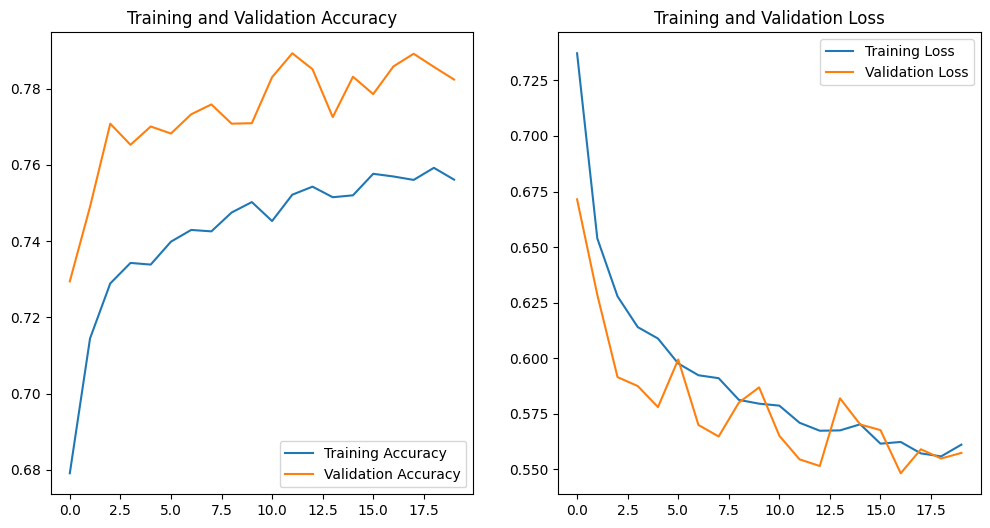

In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Update these paths to match your actual Kaggle input directory
BASE_DIR = 'dataset_cropped_fixed_cells' 
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALID_DIR = os.path.join(BASE_DIR, 'valid') # or 'val', check exact folder name
TEST_DIR  = os.path.join(BASE_DIR, 'test')

IMG_SIZE = (224, 224) # Standard size for modern CNNs
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 7  # You mentioned around 7 classes

# ==========================================
# 2. CUSTOM PREPROCESSING (Gray + Blur + Invert)
# ==========================================
def custom_preprocessing(image):
    """
    This function applies the specific logic you requested:
    1. Grayscale (if input is RGB)
    2. Gaussian Blur (Noise Removal)
    3. (Optional) Binary Inversion
    """
    # Image comes in as float or uint8. Convert to uint8 for OpenCV
    img_arr = np.array(image, dtype=np.uint8)
    
    # Check if image has 3 channels (RGB) and convert to Gray
    if len(img_arr.shape) == 3:
        gray = cv2.cvtColor(img_arr, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_arr
    
    # 1. Noise Removal (Gaussian Blur)
    # Reduces graininess
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 2. (Optional) Binary Inversion
    # CAUTION for Classification: Thresholding can sometimes hide subtle features 
    # like microcracks. If accuracy is low, comment out the next line.
    _, processed = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY_INV)
    
    # 3. Reformatting for the AI
    # CNNs often expect 3 channels. We repeat the gray channel 3 times 
    # to mimic RGB, allowing us to use powerful pre-trained models.
    processed_rgb = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)
    
    # Normalize to 0-1 range
    return img_arr # processed_rgb.astype(np.float32) / 255.0

# ==========================================
# 3. DATA GENERATORS (Loading the Data)
# ==========================================
print("Setting up Data Generators...")

# We use ImageDataGenerator because it easily handles the folder structure
# and allows our 'custom_preprocessing' function.

train_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
    rotation_range=20,      # Data Augmentation: Random rotations
    horizontal_flip=True,   # Data Augmentation: Flips
    vertical_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing
)

# Load Train Data
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Used for multi-class classification (>2 classes)
    shuffle=True
)

# Load Validation Data
valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ==========================================
# 4. MODEL ARCHITECTURE (Transfer Learning)
# ==========================================
# We use MobileNetV2 or ResNet50. They are powerful and fast.
# Here we use MobileNetV2 (great for "cropped" images and faster training).

# base_model = tf.keras.applications.MobileNetV2(
#     input_shape=IMG_SIZE + (3,), # (224, 224, 3)
#     include_top=False,           # Exclude the final classification layer
#     weights='imagenet'           # Pre-trained on generic images
# )

base_model = tf.keras.applications.EfficientNetB2(
    input_shape=IMG_SIZE + (3,), # (224, 224, 3)
    include_top=False,           # Exclude the final classification layer
    weights='imagenet'           # Pre-trained on generic images
)

base_model.trainable = False # Freeze base model initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Helps prevent overfitting
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax') # Softmax for multi-class
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 5. TRAINING
# ==========================================
print("Starting Training...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(valid_generator)
)

# ==========================================
# 6. RESULTS & SAVING
# ==========================================
# Plot Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [4]:
# Save the final model
model.save('pv_defect_classifier_model.h5')
print("Model saved as pv_defect_classifier_model.h5")

Model saved as pv_defect_classifier_model.h5


In [ ]:
def detect_cells_with_boxes(image_path):
    """
    Detect cells, compute raw brightness per cell (mean gray level) and
    compute relative brightness per your requested formula:
        relative = ((a - b) / a) * 100
    where a = brightness of brightest cell, b = brightness of cell.
    Returns (annotated_output_path, cell_detections_list)
    Each cell dict contains: cell_id, confidence, bbox, raw_brightness, relative_brightness
    """
    try:
        print(f"🔍 Running cell detection using model: {CELL_DETECTION_MODEL_PATH}")
        results = cell_detection_model(image_path, imgsz=640)
        img = cv2.imread(image_path)

        if img is None:
            return None, "Could not load image"

        boxes = results[0].boxes
        cell_detections = []
        raw_brightness_values = []

        if boxes is not None and len(boxes) > 0:
            for i, box in enumerate(boxes.xyxy):
                # convert to ints
                x1, y1, x2, y2 = map(int, box)
                conf = float(boxes.conf[i]) if boxes.conf is not None else 0.0

                # Extract ROI and compute raw brightness (mean grayscale)
                roi = img[y1:y2, x1:x2]
                raw_brightness = 0.0
                if roi.size > 0:
                    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
                    raw_brightness = float(np.mean(gray))
                raw_brightness_values.append(raw_brightness)

                # Draw rectangle and center label onto image
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # Use just the cell ID for clearer display
                label = str(i + 1)
                cx = int((x1 + x2) / 2)
                cy = int((y1 + y2) / 2)
                
                # Calculate cell dimensions
                cell_width = x2 - x1
                cell_height = y2 - y1
                
                # Calculate adaptive font scale based on cell size
                # Use the smaller dimension to ensure text fits
                base_size = min(cell_width, cell_height)
                
                # Start with a base scale and adjust based on cell size
                # Aim for text to be about 30-40% of the smaller cell dimension
                font_scale = max(0.3, min(2.0, base_size / 30.0))
                
                font = cv2.FONT_HERSHEY_SIMPLEX
                thickness = max(1, int(font_scale * 2))
                
                # Get text size to ensure it fits
                (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)
                
                # If text is too large, scale it down
                max_text_width = cell_width * 0.8  # 80% of cell width
                max_text_height = cell_height * 0.8  # 80% of cell height
                
                if tw > max_text_width or th > max_text_height:
                    # Scale down proportionally
                    scale_factor = min(max_text_width / tw, max_text_height / th, 0.95)
                    font_scale = font_scale * scale_factor
                    thickness = max(1, int(font_scale * 2))
                    (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)
                
                # Center the text in the cell
                org_x = cx - tw // 2
                org_y = cy + th // 2
                
                # Ensure text stays within cell bounds
                org_x = max(x1 + 2, min(org_x, x2 - tw - 2))
                org_y = max(y1 + th + 2, min(org_y, y2 - 2))
                
                # Draw a semi-transparent background for better visibility
                overlay = img.copy()
                cv2.rectangle(overlay, (org_x - 2, org_y - th - 2), (org_x + tw + 2, org_y + baseline + 2), (0, 0, 0), -1)
                cv2.addWeighted(overlay, 0.6, img, 0.4, 0, img)
                
                # Draw the text in bright green
                cv2.putText(img, label, (org_x, org_y), font, font_scale, (0, 255, 0), thickness)

                # Save detection with raw brightness (relative set later)
                cell_detections.append({
                    "cell_id": i + 1,
                    "confidence": conf,
                    "bbox": [x1, y1, x2, y2],
                    "raw_brightness": raw_brightness
                })

            # Determine 'a' (max raw brightness) and compute relative brightness for each cell
            a = max(raw_brightness_values) if len(raw_brightness_values) > 0 else 0.0
            if a == 0:
                # avoid division by zero: set relative to 0
                for c in cell_detections:
                    c["relative_brightness"] = 0.0
            else:
                for c in cell_detections:
                    b = c.get("raw_brightness", 0.0)
                    # formula: ((a - b)/a) * 100
                    rel = ((a - b) / a) * 100.0
                    c["relative_brightness"] = round(rel, 2)

            total_cells = len(boxes)
            cv2.putText(img, f"Total Cells Detected: {total_cells}", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

            print(f"Detected {total_cells} cells in the image")
        else:
            print("No cells detected in the image")
            cv2.putText(img, "No Cells Detected", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        # Save annotated output
        output_path = os.path.join(OUTPUT_FOLDER, f"cell_detection_{os.path.basename(image_path)}")
        success = cv2.imwrite(output_path, img)
        if success:
            print(f"✅ Cell detection image saved to: {output_path}")
            if os.path.exists(output_path):
                print(f"✅ File verified. Size: {os.path.getsize(output_path)} bytes")
        else:
            print(f"❌ Failed to save cell detection image to: {output_path}")

        # Logging brightness info
        print("Raw & Relative brightness per cell:")
        for c in cell_detections:
            print(f"Cell {c['cell_id']} -> raw: {c['raw_brightness']:.2f}, relative: {c['relative_brightness']}%")

        return output_path, cell_detections

    except Exception as e:
        print(f"Error in cell detection: {e}")
        return None, str(e)


### after cropping by  new model


In [13]:
import os
from collections import defaultdict

# Path to label folders
splits = ["train", "valid", "test"]
label_root = "cells_ELDDS1400c5-dataset-3"

# Initialize counts
counts = {split: defaultdict(int) for split in splits}
total_counts = defaultdict(int)

# Class names (optional)
classes = {0: '0 Examined',
 1: '1 ShortCircuitString',
 2: '2 ShortCircuitCell -LowPowerCell-',
 3: '3 Crack',
 4: '5 OtherError',
 5: 'DarkSpot',
 6: 'Examined',
 7: 'MicroCrack',
 8: 'Scratch'}

for split in splits:
    lbl_path = os.path.join(label_root, split, "labels")
    for fname in os.listdir(lbl_path):
        if fname.endswith(".txt"):
            with open(os.path.join(lbl_path, fname), "r") as f:
                for line in f:
                    cls_id = int(line.split()[0])
                    counts[split][cls_id] += 1
                    total_counts[cls_id] += 1


# Print counts per split
for split in splits:
    print(f"\n--- {split.upper()} ---")
    for cls_id, num in counts[split].items():
        print(f"{classes.get(cls_id, cls_id)}: {num}")

# Print total counts
print("\n--- TOTAL ---")
for cls_id, num in total_counts.items():
    print(f"{classes.get(cls_id, cls_id)}: {num}")

# Optionally compute percentages per split
print("\n--- Percentages per split ---")
for split in splits:
    total = sum(counts[split].values())
    for cls_id, num in counts[split].items():
        pct = 100 * num / total if total > 0 else 0
        print(f"{split} - {classes.get(cls_id, cls_id)}: {pct:.2f}%")


--- TRAIN ---
MicroCrack: 9282
5 OtherError: 12331
3 Crack: 395
2 ShortCircuitCell -LowPowerCell-: 696

--- VALID ---
5 OtherError: 3411
MicroCrack: 2518
3 Crack: 130
2 ShortCircuitCell -LowPowerCell-: 185

--- TEST ---
MicroCrack: 1006
5 OtherError: 1493
3 Crack: 67
2 ShortCircuitCell -LowPowerCell-: 94

--- TOTAL ---
MicroCrack: 12806
5 OtherError: 17235
3 Crack: 592
2 ShortCircuitCell -LowPowerCell-: 975

--- Percentages per split ---
train - MicroCrack: 40.88%
train - 5 OtherError: 54.31%
train - 3 Crack: 1.74%
train - 2 ShortCircuitCell -LowPowerCell-: 3.07%
valid - 5 OtherError: 54.63%
valid - MicroCrack: 40.33%
valid - 3 Crack: 2.08%
valid - 2 ShortCircuitCell -LowPowerCell-: 2.96%
test - MicroCrack: 37.82%
test - 5 OtherError: 56.13%
test - 3 Crack: 2.52%
test - 2 ShortCircuitCell -LowPowerCell-: 3.53%


In [12]:
## removing very low (almost none classes)
import os

# Classes to remove (based on class id in YOLO labels)
remove_classes = ["0", '5', '8']  # replace with actual class IDs

label_dirs = ["cells_ELDDS1400c5-dataset-3/train/labels", "cells_ELDDS1400c5-dataset-3/valid/labels", "cells_ELDDS1400c5-dataset-3/test/labels"]

for lbl_dir in label_dirs:
    for fname in os.listdir(lbl_dir):
        if not fname.endswith(".txt"):
            continue
        path = os.path.join(lbl_dir, fname)
        lines = []
        with open(path, "r") as f:
            for line in f:
                cls_id = line.split()[0]
                if cls_id not in map(str, remove_classes):
                    lines.append(line)
        # Rewrite file
        with open(path, "w") as f:
            f.writelines(lines)

In [ ]:
## update the new labels starting from 0

old_to_new = {1:0, 2:1, 3:2, 4:3, 7:4}
new_classes = {0:'1 ShortCircuitString', 1:'2 ShortCircuitCell -LowPowerCell-', 2:'3 Crack', 3:'5 OtherError', 4:'MicroCrack'}

for lbl_dir in label_dirs:
    for fname in os.listdir(lbl_dir):
        if not fname.endswith(".txt"):
            continue
        path = os.path.join(lbl_dir, fname)
        new_lines = []
        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split()
                old_id = int(parts[0])
                if old_id in old_to_new:
                    parts[0] = str(old_to_new[old_id])
                    new_lines.append(" ".join(parts) + "\n")
        with open(path, "w") as f:
            f.writelines(new_lines)



In [19]:
from ultralytics import YOLO

# Example: weights proportional to inverse frequency

model = YOLO("yolov8n.pt")
model.train(
    data="cells_ELDDS1400c5-dataset-3\data.yaml",
    imgsz=320,
    batch=16,
    epochs=150,
    rect=True,
    translate=0.1,
    scale=0.1,
    perspective=0.0,
    
    mosaic=0.0,
    amp=True
)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cells_ELDDS1400c5-dataset-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train11, nbs=64, n

KeyboardInterrupt: 

In [1]:
from ultralytics import YOLO

In [ ]:


model = YOLO("yolov8n.pt")

model.train(
    data=r"cells_ELDDS1400c5-dataset-3\data.yaml",

    imgsz=224,
    batch=16,          # start small (memory safe)
    epochs=120,
    
    # mosaic=0.0,       # VERY IMPORTANT for EL cells
    # mixup=0.0,

    # hsv_v=0.2,
    # hsv_s=0.1,

    amp=True,         # mixed precision
    cache=False,

    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cells_ELDDS1400c5-dataset-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train14, nbs=64, n

KeyboardInterrupt: 

In [1]:
# Create the P2 Architecture File
p2_yaml_content = """
# YOLOv8-P2-Medium Custom Architecture
nc: 1  # We are training ONLY on the defect
scales:
  m: [0.67, 0.75, 768] # Medium size

backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]]  # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]] # 1-P2/4  <--- KEEPING THIS LAYER
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]] # 3-P3/8
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]] # 5-P4/16
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]  # 9

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]  # cat backbone P4
  - [-1, 3, C2f, [512]]         # 12

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]  # cat backbone P3
  - [-1, 3, C2f, [256]]         # 15 (P3/8-small)

  # === THE MAGIC PART (P2) ===
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 2], 1, Concat, [1]]  # cat backbone P2 (High Res)
  - [-1, 3, C2f, [128]]         # 18 (P2/4-xsmall)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 15], 1, Concat, [1]] # cat head P3
  - [-1, 3, C2f, [256]]         # 21 (P3/8-small)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 12], 1, Concat, [1]] # cat head P4
  - [-1, 3, C2f, [512]]         # 24 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]  # cat head P5
  - [-1, 3, C2f, [1024]]        # 27 (P5/32-large)

  - [[18, 21, 24, 27], 1, Detect, [nc]] # Detect at P2, P3, P4, P5
"""

with open("yolov8-p2.yaml", "w") as f:
    f.write(p2_yaml_content)

In [2]:
from ultralytics import YOLO

# 1. Initialize the P2 Model (Empty)
model = YOLO("yolov8-p2.yaml") 

# 2. Load Weights (Transfer Learning)
# We load the standard weights to give the model a "Brain"
model.load("yolov8m.pt") 


WARNING no model scale passed. Assuming scale='m'.
Transferred 319/581 items from pretrained weights


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_

In [3]:

from ultralytics import YOLO

# model = YOLO("yolov8m.pt")

model.train(
    data=r"cells_ELDDS1400c5-dataset-3-with-healthy\data.yaml",

    imgsz=320,
    batch=32,          # start small (memory safe)
    epochs=120,
    rect=True,
    mosaic=0.0,       # VERY IMPORTANT for EL cells
    # mixup=0.0,

    # hsv_v=0.2,
    # hsv_s=0.1,

    # amp=True,         # mixed precision
    # cache=False,

    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.3.243 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cells_ELDDS1400c5-dataset-3-with-healthy\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8-p2.yaml, momentum=0.937, mosaic=0.0, multi_scale=False, name=t

KeyboardInterrupt: 

In [1]:
from ultralytics import YOLO
# hereeee
model = YOLO("yolov8m.pt")

model.train(
    data=r"cells_ELDDS1400c5-dataset-3-with-healthy\data.yaml",
    epochs=100,
    imgsz=320,
    # cls_pw=calculate_class_weights(),  # Based on your class distribution
    lr0=0.01,
    lrf=0.01,
    warmup_epochs=3,
    box=7.5,  # Increase box loss weight
    cls=0.5,  # Decrease cls loss if classes are imbalanced
    dfl=1.5,
    # fl_gamma=1.5,  # Focal loss
    mosaic=0.5,
    mixup=0.1,
    copy_paste=0.5,  # If available

    patience=15,
)

New https://pypi.org/project/ultralytics/8.3.243 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cells_ELDDS1400c5-dataset-3-with-healthy\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=tr

KeyboardInterrupt: 

In [2]:
model = YOLO(r"final_env_yolo\Lib\site-packages\ultralytics\cfg\models\v8\yolov8m-p2.yaml") # adding P2 head

model.train(
    data=r"cells_ELDDS1400c5-dataset-3\data.yaml",

    imgsz=224,
    batch=32,   
    epochs=80,
    
    mosaic=0.0, 
    
    cache=False,

    device=0,
    patience=10,
)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cells_ELDDS1400c5-dataset-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=final_env_yolo\Lib\site-packages\ultralytics\cfg\models\v8\yolov8m-p2.yaml, momentu

KeyboardInterrupt: 

In [ ]:
# model = YOLO(r"final_env_yolo\Lib\site-packages\ultralytics\cfg\models\v8\yolov8m-p2.yaml") # adding P2 head

# model.train(
#     data=r"cells_ELDDS1400c5-dataset-3\data.yaml",

#     imgsz=224,
#     batch=16,   
#     epochs=80,

#     mosaic=0.0, 

#     rect=True,
#     cache=False,

#     device=0,
#     patience=10,
# )

In [3]:
import os
import shutil
import yaml
from tqdm.notebook import tqdm

# ================= CONFIGURATION =================
# 1. Path to your ORIGINAL dataset (Read-Only Input)
#    Example: "/kaggle/input/solar-panel-faults/dataset"
SOURCE_DATASET_DIR = "cells_ELDDS1400c5-dataset-3" 

# 2. The Class ID you want to isolate (Check your original data.yaml)
#    Example: If 0=ShortCircuit, 1=Crack. Set this to 1 to train ONLY on Cracks.
TARGET_CLASS_ID = 4 
TARGET_CLASS_NAME = "Micro_crack" # Name for the new yaml

# 3. Where to create the new dataset (Writable Output)
OUTPUT_DIR = "single_class_dataset"

# ================= PROCESSING SCRIPT =================
def process_split(split_name):
    """
    Process train/val/test folders.
    Filters labels and copies matching images.
    """
    # Define paths
    src_images = os.path.join(SOURCE_DATASET_DIR, split_name, "images")
    src_labels = os.path.join(SOURCE_DATASET_DIR, split_name, "labels")
    
    dst_images = os.path.join(OUTPUT_DIR, split_name, "images")
    dst_labels = os.path.join(OUTPUT_DIR, split_name, "labels")
    
    # Create directories
    os.makedirs(dst_images, exist_ok=True)
    os.makedirs(dst_labels, exist_ok=True)
    
    # Check if source split exists
    if not os.path.exists(src_labels):
        print(f"Skipping {split_name} (folder not found in source)")
        return

    print(f"Processing {split_name}...")
    
    # Loop through all label files
    label_files = [f for f in os.listdir(src_labels) if f.endswith('.txt')]
    
    count_kept = 0
    # print(label_files)
    for label_file in label_files :
        src_label_path = os.path.join(src_labels, label_file)
        dst_label_path = os.path.join(dst_labels, label_file)
        
        # Read the label file
        with open(src_label_path, 'r') as f:
            lines = f.readlines()
            
        # FILTER: Keep only lines matching TARGET_CLASS_ID
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0:
                cls_id = int(parts[0])
                if cls_id == TARGET_CLASS_ID:
                    # RELABEL: Change class ID to 0
                    parts[0] = '0' 
                    new_lines.append(" ".join(parts) + "\n")
        
        # DECISION: Do we save this? 
        # Option A: Save ONLY if it contains the defect (Pure Positive Dataset)
        if len(new_lines) > 0:
            # 1. Save the new label file
            with open(dst_label_path, 'w') as f:
                f.writelines(new_lines)
            
            # 2. Copy the corresponding image
            # Try different extensions just in case (.jpg, .png, .jpeg)
            img_name = os.path.splitext(label_file)[0]
            copied = False
            for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
                src_img_path = os.path.join(src_images, img_name + ext)
                if os.path.exists(src_img_path):
                    shutil.copy(src_img_path, os.path.join(dst_images, img_name + ext))
                    copied = True
                    break
            
            if copied:
                count_kept += 1
                
    print(f"  -> Extracted {count_kept} images containing '{TARGET_CLASS_NAME}'")

# ================= EXECUTION =================
# 1. Clean previous run if exists
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# 2. Run for Train and Val
process_split("train")
process_split("valid") # Check if your folder is named 'valid' or 'val'
process_split("test")

# 3. Create the new YAML file
yaml_content = {
    'path': OUTPUT_DIR, # Absolute path for Kaggle
    'train': 'train/images',
    'val': 'valid/images', # Or 'val'/images depending on your folder name above
    'test': 'test/images',
    'nc': 1,
    'names': [TARGET_CLASS_NAME]
}

yaml_path = os.path.join(OUTPUT_DIR, "custom_single_class.yaml")
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=None)

print("\n✅ DONE!")
print(f"New Dataset created at: {OUTPUT_DIR}")
print(f"New YAML file created at: {yaml_path}")
print("You can now train using: model.train(data='" + yaml_path + "', ...)")


Processing train...
  -> Extracted 7585 images containing 'Micro_crack'
Processing valid...
  -> Extracted 2041 images containing 'Micro_crack'
Processing test...
  -> Extracted 762 images containing 'Micro_crack'

✅ DONE!
New Dataset created at: single_class_dataset
New YAML file created at: single_class_dataset\custom_single_class.yaml
You can now train using: model.train(data='single_class_dataset\custom_single_class.yaml', ...)


In [4]:


from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # medium

model.train(
    data=yaml_path,

    imgsz=224,
    batch=16,          # start small (memory safe)
    epochs=50,
    
    rect=True,

    mosaic=0.0,       # VERY IMPORTANT for EL cells
    # mixup=0.0,
    
    device=0,
    patience=15,
)

Exception ignored in: <function tqdm.__del__ at 0x00000214790DC160>
Traceback (most recent call last):
  File "c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
  File "c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\notebook.py", line 157, in display
    pbar.value = self.n
AttributeError: 'str' object has no attribute 'value'


Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=single_class_dataset\custom_single_class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train40, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspect

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021505F39630>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [7]:


from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # medium

model.train(
    data=r'single_class_dataset\custom_single_class.yaml',

    imgsz=640,
    batch=16,          # start small (memory safe)
    epochs=80,
    
    rect=True,

    mosaic=0.0,       # VERY IMPORTANT for EL cells
    # mixup=0.0,
    
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=single_class_dataset\custom_single_class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train46, nb

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025AEF8ACF40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [6]:

# import os
# import random
# import yaml

# # ================= CONFIGURATION =================
# DATASET_ROOT = "cells_ELDDS1400c5-dataset-3"  # Your root folder
# TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "train/images")
# VAL_IMG_DIR = os.path.join(DATASET_ROOT, "valid/images")
# OUTPUT_TXT_DIR = "dataset_shuffled"

# # ================= EXECUTION =================
# os.makedirs(OUTPUT_TXT_DIR, exist_ok=True)

# def create_shuffled_list(image_dir, output_name):
#     # 1. Get all image files
#     images = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
#               if f.endswith(('.jpg', '.png', '.jpeg'))]
    
#     # 2. THE SHUFFLE (Critical Step)
#     random.shuffle(images)
    
#     # 3. Save to .txt file
#     output_path = os.path.join(OUTPUT_TXT_DIR, output_name)
#     with open(output_path, 'w') as f:
#         f.write('\n'.join(images))
    
#     print(f"✅ Created {output_path} with {len(images)} shuffled images.")
#     return output_path

# # Create the lists
# train_txt = create_shuffled_list(TRAIN_IMG_DIR, "train_shuffled.txt")
# val_txt = create_shuffled_list(VAL_IMG_DIR, "val_shuffled.txt")

# # ================= CREATE NEW YAML =================
# # We need a yaml that points to the .txt files, not the folders

# yaml_data = {
#     'path': os.path.abspath(DATASET_ROOT), # Absolute path is safer
#     'train': os.path.abspath(train_txt),   # Point to the list, not the folder
#     'val': os.path.abspath(val_txt),       # Point to the list
#     'nc': 5,                               # Update this if needed
#     'names': ['ShortCircuitString', 'ShortCircuitCell', 'Crack', 'OtherError', 'MicroCrack']                     # Update this if needed

# }

# yaml_path = "shuffled_data.yaml"
# with open(yaml_path, 'w') as f:
#     yaml.dump(yaml_data, f, default_flow_style=None)

# print(f"🚀 Ready! Use 'data={yaml_path}' in your training command.")



In [8]:
# Create the P2 Architecture File
p2_yaml_content = """
# YOLOv8-P2-Medium Custom Architecture
nc: 1  # We are training ONLY on the defect
scales:
  m: [0.67, 0.75, 768] # Medium size

backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]]  # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]] # 1-P2/4  <--- KEEPING THIS LAYER
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]] # 3-P3/8
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]] # 5-P4/16
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]  # 9

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]  # cat backbone P4
  - [-1, 3, C2f, [512]]         # 12

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]  # cat backbone P3
  - [-1, 3, C2f, [256]]         # 15 (P3/8-small)

  # === THE MAGIC PART (P2) ===
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 2], 1, Concat, [1]]  # cat backbone P2 (High Res)
  - [-1, 3, C2f, [128]]         # 18 (P2/4-xsmall)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 15], 1, Concat, [1]] # cat head P3
  - [-1, 3, C2f, [256]]         # 21 (P3/8-small)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 12], 1, Concat, [1]] # cat head P4
  - [-1, 3, C2f, [512]]         # 24 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]  # cat head P5
  - [-1, 3, C2f, [1024]]        # 27 (P5/32-large)

  - [[18, 21, 24, 27], 1, Detect, [nc]] # Detect at P2, P3, P4, P5
"""

with open("yolov8-p2.yaml", "w") as f:
    f.write(p2_yaml_content)

In [9]:
from ultralytics import YOLO

# 1. Initialize the P2 Model (Empty)
model = YOLO("yolov8-p2.yaml") 

# 2. Load Weights (Transfer Learning)
# We load the standard weights to give the model a "Brain"
model.load("yolov8m.pt") 

# 3. Train with "Copy-Paste"
model.train(
    data=r'single_class_dataset\custom_single_class.yaml',
    epochs=100,
    imgsz=640,
    rect=True,
    batch=16,           # P2 uses more memory, so lower batch is safer
    mosaic=0.0,        # Keep Mosaic OFF
    
    # === THE BOOSTERS ===
    # copy_paste=0.3,    # 30% chance to copy-paste defects (Crucial for recall)
    # degrees=10.0,      # Slight rotation to catch diagonal grid breaks
    # hsv_v=0.4,         # Contrast variation
    name="P2_CopyPaste_Run"
)

WARNING no model scale passed. Assuming scale='m'.
Transferred 319/581 items from pretrained weights
New https://pypi.org/project/ultralytics/8.3.241 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.238  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=single_class_dataset\custom_single_class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mi

KeyboardInterrupt: 

In [ ]:
C:\Users\Rowan\Documents\Rowan\Yolo_test\runs\detect\train63\weights\best.pt...
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.5it/s 5.7s0.3s
                   all        624       8611      0.673      0.592      0.619      0.428
              examined        411        411      0.997          1      0.995      0.995
           micro_crack        323       3059       0.71      0.634      0.662       0.28
                 crack        123        644      0.581      0.379      0.418      0.206
              low_cell        148       1297      0.728      0.665      0.725      0.548
            low_string         19         74      0.668      0.986      0.966      0.814
         isolated_area         82        377      0.701      0.255      0.312      0.153
         contamination         33        928      0.506       0.49      0.507      0.295
           other_error        297       1821      0.496      0.328      0.366      0.137

In [ ]:
C:\Users\Rowan\Documents\Rowan\Yolo_test\runs\detect\train65\weights\best.pt...
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 5.9it/s 6.6s0.2s
                   all        624       8611       0.73      0.643      0.683      0.475
              examined        411        411      0.998          1      0.995      0.994
           micro_crack        323       3059      0.785      0.723      0.764      0.361
                 crack        123        644       0.68       0.55      0.571      0.299
              low_cell        148       1297      0.722       0.71      0.775      0.605
            low_string         19         74        0.8      0.932       0.95      0.811
         isolated_area         82        377      0.703      0.297      0.367      0.199
         contamination         33        928      0.574       0.54      0.569      0.343
           other_error        297       1821      0.577      0.389      0.471      0.189

In [ ]:
from ultralytics import YOLO

# better than not enhanced . in  cells det
# better than same with mosaic = 0   . in  cells det
model = YOLO("yolov8m.pt")

model.train(
    data=r"modified_mixed_pv_orig_res\data.yaml",

    imgsz=960,
    batch=16,          # start small (memory safe)
    epochs=50,
    mosaic=0.0,       # VERY IMPORTANT for EL cells
    # mixup=0.0,

    # hsv_v=0.2,
    # hsv_s=0.1,

    device=0,
    patience=15,
)

#  move following to script or isolate script

Scanning 624 files...


  0%|          | 0/624 [00:00<?, ?it/s]

100%|██████████| 624/624 [00:02<00:00, 253.20it/s]
C:\Users\Rowan\AppData\Local\Temp\ipykernel_6164\555183061.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)



Class           | Count    | Median Size  | Outliers
0 Examined      | 217      | 0.6146       | 13      
1 ShortCircuitString | 74       | 0.1037       | 1       
2 ShortCircuitCell -LowPowerCell- | 170      | 0.0070       | 10      
3 Crack         | 75       | 0.0012       | 0       
4 MicroCrack    | 1641     | 0.0003       | 141     
5 OtherError    | 1279     | 0.0009       | 135     
Backsheet Scratch | 23       | 0.0012       | 2       
Branch Cracks   | 238      | 0.0085       | 0       
Branch crack    | 28       | 0.0012       | 0       
Dark Cell       | 4        | 0.0131       | 1       
Examined        | 1        | 0.3216       | 0       
Fingerline Interruption | 43       | 0.0002       | 3       
Isolated area   | 42       | 0.0002       | 4       
Isolation Area  | 344      | 0.0004       | 25      
Micro crack     | 101      | 0.0004       | 8       
Microcracks     | 566      | 0.0010       | 20      
Partially Dark  | 115      | 0.0067       | 12      
Poor Ribbon 

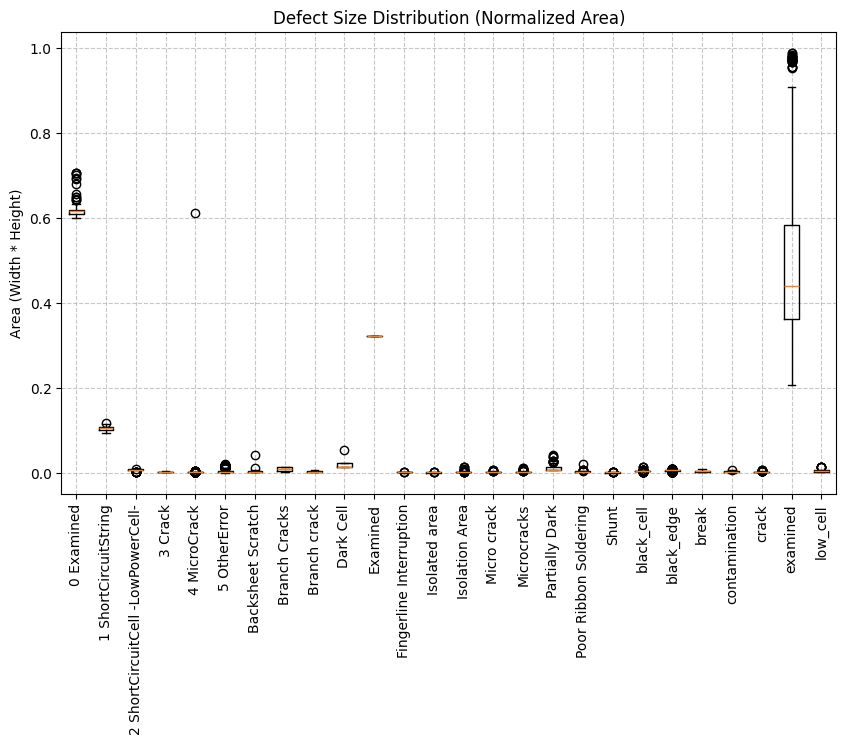


[Info] Boxplot generated. Close window to see detailed list.

============================== DETAILED OUTLIER REPORT ==============================

Class: 0 Examined (Bounds: 0.5940 - 0.6336)
  [Too HUGE] File: panel_2021_05_28__20_Image__2021-06-01__12-34-56_54V_5sec_jpg.rf.cb84d6aea76e07c7b5c9ce67aa57d6e5.txt (Line 1) - Area: 0.7050
  [Too HUGE] File: panel_09_Image__2021-05-31__10-45-09_50V_5sec_jpg.rf.8eaaebafa53cf62bd5801ea3c2235194.txt (Line 1) - Area: 0.7049
  [Too HUGE] File: panel_2021_05_28__18_Image__2021-06-01__12-50-15_53V_3sec_jpg.rf.c318828d71b24bec1fb13cca2267adb1.txt (Line 1) - Area: 0.7039
  [Too HUGE] File: panel_2021_05_28__07_Image__2021-06-01__13-55-54_54V_5sec_jpg.rf.5ba65bdad55f24c3b239264b484728db.txt (Line 1) - Area: 0.7002
  [Too HUGE] File: panel_01_Image__2021-05-31__10-54-53_50V_5sec_jpg.rf.a84db9c66fa5c211e30c69baabb115e6.txt (Line 1) - Area: 0.6927
  [Too HUGE] File: panel_03_Image__2021-05-31__10-48-11_50V_5sec_jpg.rf.ce935904040b50f0bc9f17d6d93f0ac4.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

# --- CONFIGURATION ---
LABELS_DIR = r"pv-last-version--2-2\train\labels"  # Update this path
LABELS_DIR = r"pv-last-version--2-2\valid\labels"  # Update this path
# Optional: Map IDs to names for better readability
CLASS_NAMES = dict(enumerate(['0 Examined', '1 ShortCircuitString', '2 ShortCircuitCell -LowPowerCell-', '3 Crack', '4 MicroCrack', '5 OtherError', 'Backsheet Scratch', 'Branch Cracks', 'Branch crack', 'Contamination', 'Dark Cell', 'DarkSpot', 'Examined', 'Fingerline Interruption', 'Isolated area', 'Isolation Area', 'Micro crack', 'MicroCrack', 'Microcracks', 'Partially Dark', 'Poor Ribbon Soldering', 'Scratch', 'Shunt', 'black_cell', 'black_edge', 'break', 'contamination', 'crack', 'examined', 'low_cell']))

def load_yolo_labels(folder_path):
    """
    Reads all txt files and aggregates bounding box areas by class.
    Stores metadata (filename, line_index) to locate the outliers later.
    """
    # Structure: { class_id: [ {'area': float, 'file': str, 'bbox': list} ] }
    class_data = defaultdict(list)
    
    files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
    print(f"Scanning {len(files)} files...")

    for file in tqdm(files):
        with open(os.path.join(folder_path, file), 'r') as f:
            lines = f.readlines()

        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) < 5: continue
            
            cls_id = int(parts[0])
            # YOLO format: class x_center y_center width height
            w = float(parts[3])
            h = float(parts[4])
            area = w * h  # Normalized area (0.0 to 1.0)
            
            class_data[cls_id].append({
                'area': area,
                'file': file,
                'line': i + 1,
                'w': w,
                'h': h
            })
    return class_data

def detect_outliers(class_data):
    print("\n" + "="*60)
    print(f"{'Class':<15} | {'Count':<8} | {'Median Size':<12} | {'Outliers':<8}")
    print("="*60)

    stats = {}

    for cls_id, items in sorted(class_data.items()):
        areas = np.array([item['area'] for item in items])
        
        # Calculate IQR (Interquartile Range)
        Q1 = np.percentile(areas, 25)
        Q3 = np.percentile(areas, 75)
        IQR = Q3 - Q1
        
        # Define bounds. 1.5 is standard, 3.0 is "extreme" outliers
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        
        outliers = [item for item in items if item['area'] < lower_bound or item['area'] > upper_bound]
        
        cls_name = CLASS_NAMES.get(cls_id, str(cls_id))
        print(f"{cls_name:<15} | {len(items):<8} | {np.median(areas):.4f}       | {len(outliers):<8}")
        
        stats[cls_id] = {
            'outliers': outliers,
            'areas': areas,
            'bounds': (lower_bound, upper_bound),
            'name': cls_name
        }

    return stats

def plot_boxplots(stats):
    """Generates a boxplot to visualize size distributions."""
    data_to_plot = []
    labels = []
    
    for cls_id, data in stats.items():
        data_to_plot.append(data['areas'])
        labels.append(data['name'])
    
    plt.figure(figsize=(10, 6))
    plt.boxplot(data_to_plot, labels=labels)
    plt.title("Defect Size Distribution (Normalized Area)")
    plt.ylabel("Area (Width * Height)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=90)
    plt.show()
    print("\n[Info] Boxplot generated. Close window to see detailed list.")

# --- EXECUTION ---
if __name__ == "__main__":
    data = load_yolo_labels(LABELS_DIR)
    
    if not data:
        print("No data found! Check your path.")
    else:
        statistics = detect_outliers(data)
        plot_boxplots(statistics)
        
        # Print detailed report for the first 5 outliers of each class
        print("\n" + "="*30 + " DETAILED OUTLIER REPORT " + "="*30)
        for cls_id, stat in statistics.items():
            if not stat['outliers']: continue
            
            print(f"\nClass: {stat['name']} (Bounds: {stat['bounds'][0]:.4f} - {stat['bounds'][1]:.4f})")
            # Sort by deviation from median (most extreme first)
            sorted_outliers = sorted(stat['outliers'], key=lambda x: x['area'], reverse=True)
            
            for item in sorted_outliers[:10]: # Show top 10 worst offenders
                condition = "Too HUGE" if item['area'] > stat['bounds'][1] else "Too TINY"
                print(f"  [{condition}] File: {item['file']} (Line {item['line']}) - Area: {item['area']:.4f}")

In [8]:
import os
import cv2
import numpy as np
from collections import defaultdict
from pathlib import Path

# --- CONFIGURATION ---
DATASET_ROOT = r"Mixed-PV---Original-Res-1\train"  # Root folder containing images/ and labels/
DATASET_ROOT = r"pv-last-version--2-2\valid"  # Root folder containing images/ and labels/
IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
LABELS_DIR = os.path.join(DATASET_ROOT, "labels")
OUTPUT_DIR = "outlier_debug_images_valid"     # Where to save the check images

CLASS_NAMES = dict(enumerate(['0 Examined', '1 ShortCircuitString', '2 ShortCircuitCell -LowPowerCell-', '3 Crack', '4 MicroCrack', '5 OtherError', 'Backsheet Scratch', 'Branch Cracks', 'Branch crack', 'Contamination', 'Dark Cell', 'DarkSpot', 'Examined', 'Fingerline Interruption', 'Isolated area', 'Isolation Area', 'Micro crack', 'MicroCrack', 'Microcracks', 'Partially Dark', 'Poor Ribbon Soldering', 'Scratch', 'Shunt', 'black_cell', 'black_edge', 'break', 'contamination', 'crack', 'examined', 'low_cell']))


def get_outliers(labels_path):
    """Scans dataset and identifies outliers using IQR method."""
    class_data = defaultdict(list)
    files = [f for f in os.listdir(labels_path) if f.endswith('.txt')]

    print("Scanning labels...")
    for file in files:
        with open(os.path.join(labels_path, file), 'r') as f:
            lines = f.readlines()
        
        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls_id = int(parts[0])
            w, h = float(parts[3]), float(parts[4])
            
            class_data[cls_id].append({
                'file': file,
                'line': i,          # Keep track of line number to identify exact box
                'area': w * h,
                'bbox_norm': [float(x) for x in parts[1:]] # x, y, w, h
            })

    outliers_by_class = {}
    
    for cls_id, items in class_data.items():
        areas = np.array([x['area'] for x in items])
        Q1, Q3 = np.percentile(areas, 25), np.percentile(areas, 75)
        IQR = Q3 - Q1

        margin = 2.5 * IQR
        lower = Q1 - margin
        upper = Q3 + margin
        
        # Filter outliers
        outliers = []
        for item in items:
            if item['area'] < lower or item['area'] > upper:
                item['type'] = "TOO_BIG" if item['area'] > upper else "TOO_SMALL"
                item['severity'] = abs(item['area'] - np.median(areas)) # Distance from median
                outliers.append(item)
        
        outliers_by_class[cls_id] = outliers
        
    return outliers_by_class

def draw_and_save(outliers_map):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"\nGeneratng images in '{OUTPUT_DIR}'...")

    for cls_id, outliers in outliers_map.items():
        cls_name = CLASS_NAMES.get(cls_id, str(cls_id))
        
        # Sort by severity (worst outliers first) and take top 5
        top_5 = sorted(outliers, key=lambda x: x['severity'], reverse=True) #[:5]
        
        if not top_5:
            continue
            
        # print(f"Processing top 5 outliers for class: {cls_name}")

        for idx, item in enumerate(top_5):
            # 1. Load Image
            img_name = item['file'].replace('.txt', '.jpg') # Change extension if needed (.png)
            img_path = os.path.join(IMAGES_DIR, img_name)
            
            img = cv2.imread(img_path)
            if img is None:
                print(f"  [Warning] Image not found: {img_name}")
                continue
                
            h_img, w_img, _ = img.shape

            # 2. Parse the outlier box coordinates
            cx, cy, w, h = item['bbox_norm']
            x1 = int((cx - w/2) * w_img)
            y1 = int((cy - h/2) * h_img)
            x2 = int((cx + w/2) * w_img)
            y2 = int((cy + h/2) * h_img)

            # 3. Draw the OUTLIER box in RED (Thick)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 3)
            
            # Label: Type and Area
            label = f"{item['type']} (Area: {item['area']:.4f})"
            cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            
            # 4. Save to disk
            out_name = f"{cls_name}_rank{idx+1}_{item['type']}_{img_name}"
            cv2.imwrite(os.path.join(OUTPUT_DIR, out_name), img)

    print("\nDone! Check the folder:", OUTPUT_DIR)

if __name__ == "__main__":
    outliers = get_outliers(LABELS_DIR)
    draw_and_save(outliers)

Scanning labels...

Generatng images in 'outlier_debug_images_valid'...

Done! Check the folder: outlier_debug_images_valid


In [2]:
import os

In [ ]:
filtered_lst = []
for img_path in os.listdir('outlier_debug_images_valid'):
    if 'SMALL' in img_path: #'xamined' in img_path and 
        print(img_path)
        # filtered_lst.append(img_path.split('TOO_BIG_')[0] + " " + img_path.split('TOO_BIG_')[-1])

# with open('big_anno.txt', 'w') as f:
#     f.writelines("\n".join(filtered_lst))

ashel el no3 da

000322.JPG
000401

### check and remove 0 labels

In [1]:
import os

In [ ]:
base_lbl = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\modified_mixed_pv_orig_res_final_for integration\train\labels\\"
labels = os.listdir(base_lbl)

for lbl in labels:
    with open(base_lbl+lbl, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            if '0' in parts[0]:
                print(lbl)


In [ ]:
#defets

In [1]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",

    imgsz=640,
    batch=16,          # start small (memory safe)
    epochs=50,

    mosaic=1.0,       # VERY IMPORTANT for EL cells
    
    workers=2,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.4 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train96, nbs=64, nms=False

KeyboardInterrupt: 

In [1]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=50,

    mosaic=1.0,       # VERY IMPORTANT for EL cells
    
    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train97, nbs=64, nms=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000244BF1D8C70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

In [2]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=80,

    # mosaic=1.0,       # VERY IMPORTANT for EL cells
    copy_paste=0.5,
    flipud=0.5,

    degrees=0.1,

    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=0.1, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train98, nbs=64, nms=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000244C34A1DE0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

In [4]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=80,

    # mosaic=1.0,       # VERY IMPORTANT for EL cells
    copy_paste=0.5,
    flipud=0.5,

    degrees=0.1,

    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=0.1, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train100, nbs=64, nms=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000244C36D7C10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=80,

    # mosaic=1.0,       # VERY IMPORTANT for EL cells
    copy_paste=0.5,
    flipud=0.5,

    degrees=0.1,

    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=0.1, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train101, nbs=64, nms=Fals

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=80,

    mosaic=0.0,       # VERY IMPORTANT for EL cells
    copy_paste=0.5,
    flipud=0.5,

    translate=0.4,
    degrees=0.1,

    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.6 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=0.1, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train114, nbs=64, nms=Fals

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 28.116.6 MB/s, size: 14.2 KB)
val: Scanning C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_cropped_ready_integ\valid\labels... 7008 images, 1401 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8409/8409 1.3Kit/s 6.4s0.1s
val: New cache created: C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_cropped_ready_integ\valid\labels.cache
Plotting labels to C:\Users\Rowan\Documents\Rowan\Yolo_test\runs\detect\train114\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 320 train, 320 val
Using 4 dataloade

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",

    imgsz=224,
    batch=16,          # start small (memory safe)
    epochs=80,

    # mosaic=1.0,       # VERY IMPORTANT for EL cells
    copy_paste=0.5,
    flipud=0.5,

    degrees=0.1,

    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=0.1, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train99, nbs=64, nms=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000244C34A16C0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

In [5]:
from ultralytics import YOLO
model = YOLO("yolo11s.pt") # or yolov8s.pt

model.train(
    data=r"pv_cropped_ready_integ\data.yaml",
    
    # 1. RESOLUTION FIX
    imgsz=640,          # Increased to see thin cracks
    
    # 2. BATCH SIZE (adjust based on GPU VRAM)
    batch=16,            # Lower batch to fit higher res
    
    epochs=100,         # More epochs for higher res
    
    # 3. AUGMENTATION TUNING
    mosaic=0.0,         # Keep 0 if you have clean single-cell crops
    mixup=0.15,         # Adds robustness without cutting cells
    copy_paste=0.0,     # Turn off for now. Copy-paste on top of grid lines looks fake.
    
    # EL Specific Augs
    hsv_v=0.4,          # Randomize brightness (Crucial for EL)
    # blur=0.1,           # Simulate focus variations
    # contrast=0.2,       # Simulate current variations
    
    # Geometric Augs
    scale=0.5,          # Zoom in/out (helps detect large vs small defects)
    flipud=0.5,         # Vertical flip is fine
    fliplr=0.5,         # Horizontal flip is fine (cells are symmetric)
    translate=0.1,      # Small translation only
    degrees=5.0,       # Slight rotation
    
    # 4. OPTIMIZER TWEAKS
    lr0=0.001,          # Slightly lower learning rate for stability at high res
    box=10.0,           # Higher box gain to tighten mAP50-95
    
    workers=4,
    device=0,
    patience=20,
)

New https://pypi.org/project/ultralytics/8.4.6 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train117, nbs=64, nms=

OutOfMemoryError: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 8.00 GiB of which 1.08 GiB is free. Of the allocated memory 3.88 GiB is allocated by PyTorch, and 97.31 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# resume training
from ultralytics import YOLO

model = YOLO(r"runs\detect\train117\weights\last.pt") 

results = model.train(resume=True)


New https://pypi.org/project/ultralytics/8.4.6 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_integ\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=runs\detect\train117\weights\last.pt, momentum=0.937, mosaic=0.0, multi_scale=False, n

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 75.020.4 MB/s, size: 14.2 KB)
val: Scanning C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_cropped_ready_integ\valid\labels.cache... 7008 images, 1401 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8409/8409 8.4Mit/s 0.0s
Plotting labels to C:\Users\Rowan\Documents\Rowan\Yolo_test\runs\detect\train117\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Resuming training runs\detect\train117\weights\last.pt from epoch 56 to 100 total epochs
Image sizes 640 train, 640 val
Using 4 dataloader workers
Loggi

In [ ]:
pv_mixed_crop_orig_res_final_for_integ_more_cls

28,676 Files, train 
8,056 Files, valid images
3,792 Files, Test

In [ ]:
import cv2
import os
import glob

# Paths
input_folder = r"pv_cropped_ready_integ\train\images"  # Your raw TRAINING images 
output_folder = r"pv_cropped_ready_clahe\train\images" # New folder

# Create output folder
os.makedirs(output_folder, exist_ok=True)

# Initialize CLAHE
# clipLimit: Threshold for contrast limiting (2.0 is standard, try 3.0 or 4.0 for aggressive)
# tileGridSize: Size of grid for histogram equalization (8x8 is standard)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Process images
image_paths = glob.glob(os.path.join(input_folder, "*.jpg")) # or .jpg

print(f"Found {len(image_paths)} images. Processing...")

for img_path in image_paths:
    # Read image (grayscale is enough for EL, but YOLO usually needs 3 channels)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply CLAHE
    img_clahe = clahe.apply(img)
    
    # Convert back to BGR (3 channels) because YOLO expects RGB/BGR input
    img_bgr = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)
    
    # Save
    filename = os.path.basename(img_path)
    cv2.imwrite(os.path.join(output_folder, filename), img_bgr)

print("Processing complete!")

Found 29545 images. Processing...
Processing complete!


In [4]:
from ultralytics import YOLO
model = YOLO("yolo11s.pt") # or yolov8s.pt

model.train(
    data=r"pv_cropped_ready_clahe\data.yaml",
    
    # 1. RESOLUTION FIX
    imgsz=640,          # Increased to see thin cracks
    
    # 2. BATCH SIZE (adjust based on GPU VRAM)
    batch=16,            # Lower batch to fit higher res
    
    epochs=100,         # More epochs for higher res
    
    # 3. AUGMENTATION TUNING
    mosaic=0.0,         # Keep 0 if you have clean single-cell crops
    mixup=0.15,         # Adds robustness without cutting cells
    copy_paste=0.0,     # Turn off for now. Copy-paste on top of grid lines looks fake.
    
    # EL Specific Augs
    hsv_v=0.4,          # Randomize brightness (Crucial for EL)
    # blur=0.1,           # Simulate focus variations
    # contrast=0.2,       # Simulate current variations
    
    # Geometric Augs
    scale=0.5,          # Zoom in/out (helps detect large vs small defects)
    flipud=0.5,         # Vertical flip is fine
    fliplr=0.5,         # Horizontal flip is fine (cells are symmetric)
    translate=0.1,      # Small translation only
    degrees=5.0,       # Slight rotation
    
    # 4. OPTIMIZER TWEAKS
    # lr0=0.001,          # Slightly lower learning rate for stability at high res
    box=10.0,           # Higher box gain to tighten mAP50-95
    
    workers=4,
    device=0,
    patience=20,
)

New https://pypi.org/project/ultralytics/8.4.6 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_cropped_ready_clahe\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train123, nbs=64, nms=F

KeyboardInterrupt: 

In [ ]:
Train images
193,446 Files, 
24,621 Files, labels


valid
59,177 Files,
7008

In [1]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=r"pv_mixed_crop_orig_res_before_merge\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=50,

    mosaic=1.0,       # VERY IMPORTANT for EL cells
    
    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_mixed_crop_orig_res_before_merge\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train145, nbs

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 77.068.1 MB/s, size: 23.4 KB)
val: Scanning C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_before_merge\valid\labels... 6505 images, 45140 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51645/51645 4.8Kit/s 10.7s0.1s
val: New cache created: C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_before_merge\valid\labels.cache
Plotting labels to C:\Users\Rowan\Documents\Rowan\Yolo_test\runs\detect\train145\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 320 tr

KeyboardInterrupt: 

In [2]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=r"pv_mixed_crop_orig_res_after_merge\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=50,

    mosaic=1.0,       # VERY IMPORTANT for EL cells
    
    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_mixed_crop_orig_res_after_merge\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train147, nbs=

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.1 ms, read: 2.72.3 MB/s, size: 31.8 KB)
val: Scanning C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_after_merge\valid\labels... 6115 images, 1223 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7338/7338 965.2it/s 7.6s0.0s
val: C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_after_merge\valid\images\000048_JPG.rf.34d2601e39cf39b75751e509e0174049_cell36.jpg: 1 duplicate labels removed
val: C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_after_merge\valid\images\000065_jpg.rf.5cf82a6c958bcc8ad0b1eaa5302c088d_cell7.jpg: 1 duplicate labels removed
val: New cache created: C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_after_merge\valid\labels.cache
Plotting labels to C:\Users\Rowan\Doc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001928F3FC2B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

In [ ]:
yrain97

Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 263/263 14.0it/s 18.8s<0.1s
                   all       8409       8218      0.739      0.687      0.739      0.493
           micro_crack       2123       2521      0.825      0.768      0.812      0.441
                 crack        347        377      0.777      0.748      0.791      0.513
              low_cell        896        905      0.867      0.838      0.907      0.869
         isolated_area        314        368      0.583      0.451      0.502      0.312
         contamination        828        980      0.658      0.634      0.703      0.485
           other_error       2938       3067      0.724      0.686      0.719      0.341

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=r"pv_mixed_crop_orig_res_after_merge\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=50,

    mosaic=1.0,       # VERY IMPORTANT for EL cells
    
    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_mixed_crop_orig_res_after_merge\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train149, nbs=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000019291B65B10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

In [1]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(
    data=r"pv_mixed_crop_orig_res_after_merge\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=50,

    mosaic=1.0,       # VERY IMPORTANT for EL cells
    
    workers=4,
    device=0,
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pv_mixed_crop_orig_res_after_merge\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train151, nbs=

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.1 ms, read: 15.018.6 MB/s, size: 22.6 KB)
val: Scanning C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_after_merge\valid\labels.cache... 6115 images, 1223 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7338/7338 7.4Mit/s 0.0s
val: C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_after_merge\valid\images\000048_JPG.rf.34d2601e39cf39b75751e509e0174049_cell36.jpg: 1 duplicate labels removed
val: C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_mixed_crop_orig_res_after_merge\valid\images\000065_jpg.rf.5cf82a6c958bcc8ad0b1eaa5302c088d_cell7.jpg: 1 duplicate labels removed
Plotting labels to C:\Users\Rowan\Documents\Rowan\Yolo_test\runs\detect\train151\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' an

KeyboardInterrupt: 

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=r"pv_mixed_crop_orig_res_after_merge\data.yaml",

    imgsz=320,
    batch=16,          # start small (memory safe)
    epochs=50,

    mosaic=1.0,       # VERY IMPORTANT for EL cells
    
    workers=4,
    device=0,
    patience=15,
)